# Gerador de superfícies de ração a partir do YAML

Este notebook lê `catalogo_superficies(2).yaml` e gera uma superfície matemática `y = f(x, z)` para cada configuração.

O YAML já está preparado para uso direto pelo código:

- letras gregas foram substituídas por nomes em ASCII;
- números usam ponto como separador decimal;
- unidades ficam no nome dos parâmetros, como `lambda_m`, `beta_deg` e `a0_m`;
- valores numéricos são carregados pelo YAML diretamente como `int` ou `float`.

Por isso, este notebook não precisa mais fazer parsing de strings como `1,15 m` ou `30°`.

A geometria usada inicialmente é:

- `R = 1.15 m`
- `H = 2.50 m`
- `H0 = 0.00 m`

Para parâmetros com `nu: auto`, o relevo é centralizado verticalmente no intervalo `[0, H]`.


In [ ]:
from pathlib import Path

import numpy as np
import yaml
import matplotlib.pyplot as plt

CONFIGS_DIR = Path("../configs")
OUT_DIR = Path("../out")

YAML_PATH = CONFIGS_DIR / "catalogo_superficies.yaml"
OUTPUT_DIR = OUT_DIR / "superficies_geradas"

R = 1.15
H = 2.50
H0 = 0.00
GRID_SIZE = 140

OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Ler o catálogo YAML

Cada superfície possui:

```text
id
tipo
parametros
```

Os parâmetros numéricos já são carregados diretamente como números. Não é necessário remover unidades, trocar vírgulas ou interpretar caracteres especiais.


In [2]:
with YAML_PATH.open("r", encoding="utf-8") as f:
    catalogo = yaml.safe_load(f)["superficies"]

print(f"{len(catalogo)} superfícies carregadas")
print(catalogo[0])


45 superfícies carregadas
{'id': 1, 'tipo': 'Plana (assentada)', 'parametros': {'lambda_m': 1.0, 'beta_deg': 0, 'nu': 0.95, 'a0_m': 0.03}}


## 2. Conferir o formato dos parâmetros

Como o YAML já está normalizado, podemos acessar diretamente valores como:

```python
parametros["lambda_m"]
parametros["beta_deg"]
parametros["a0_m"]
```

A única exceção textual intencional é `nu: auto`.


In [ ]:
primeira = catalogo[0]["parametros"]

print("lambda_m:", primeira["lambda_m"], type(primeira["lambda_m"]))
print("beta_deg:", primeira["beta_deg"], type(primeira["beta_deg"]))
print("nu:", primeira["nu"], type(primeira["nu"])) # nível vertical base da superfície da ração ou seja o nivel da racao
print("a0_m:", primeira["a0_m"], type(primeira["a0_m"]))


lambda_m: 1.0 <class 'float'>
beta_deg: 0 <class 'int'>
nu: 0.95 <class 'float'>
a0_m: 0.03 <class 'float'>


## 3. Criar o domínio circular do silo

`X` e `Z` representam o plano horizontal da superfície da ração.

Somente os pontos dentro de `x² + z² ≤ R²` pertencem ao silo.


In [4]:
eixo = np.linspace(-R, R, GRID_SIZE)
X, Z = np.meshgrid(eixo, eixo)

RAIO = np.sqrt(X**2 + Z**2)
MASCARA_SILO = RAIO <= R


## 4. Rugosidade e posicionamento vertical

A rugosidade usa `lambda_m`, `beta_deg` e `a0_m` diretamente do YAML.

Quando `nu` é numérico, usamos `b = nu * H`.

Quando `nu` é `auto`, calculamos `b` de forma que o relevo fique centralizado verticalmente em `[0, H]`.


In [5]:
def rugosidade(x, z, lambda_m, beta_deg):
    beta = np.deg2rad(beta_deg)

    ub = x * np.cos(beta) + z * np.sin(beta)
    vb = -x * np.sin(beta) + z * np.cos(beta)

    return (
        0.62 * np.sin(2 * np.pi * ub / lambda_m)
        + 0.38 * np.cos(4 * np.pi * vb / lambda_m)
    )


def base_automatica(relevo):
    valores = relevo[MASCARA_SILO]
    minimo = np.nanmin(valores)
    maximo = np.nanmax(valores)

    return H / 2 - (minimo + maximo) / 2


def finalizar_superficie(relevo, parametros):
    nu = parametros["nu"]

    if nu == "auto":
        b = base_automatica(relevo)
    else:
        b = nu * H

    lambda_m = parametros["lambda_m"]
    beta_deg = parametros["beta_deg"]
    a0_m = parametros["a0_m"]

    Y = b + relevo + a0_m * rugosidade(X, Z, lambda_m, beta_deg)
    Y = np.clip(Y, 0, H)
    Y = np.where(MASCARA_SILO, Y, np.nan)

    return Y


## 5. Implementar os 9 tipos de superfície

A função escolhe a equação a partir do campo `tipo` e usa os parâmetros já numéricos do YAML diretamente.


In [6]:
def gerar_superficie(item):
    tipo = item["tipo"]
    p = item["parametros"]

    r = RAIO
    A = 0.4 * R

    if tipo == "Plana (assentada)":
        relevo = np.zeros_like(X)
        return finalizar_superficie(relevo, p)

    if tipo == "Monte lateral com cratera central":
        epsilon = p["epsilon"]
        alpha = p["alpha"]
        depth_factor = p["depth_factor"]
        theta = np.deg2rad(p["theta_deg"])
        phi = np.deg2rad(p["phi_deg"])

        cx = epsilon * R * np.cos(theta)
        cz = epsilon * R * np.sin(theta)

        distancia = np.sqrt((X - cx) ** 2 + (Z - cz) ** 2)

        monte = np.tan(phi) * np.maximum(0, alpha * R - distancia)
        cratera = -depth_factor * A + np.tan(phi) * r

        relevo = np.minimum(monte, cratera)

        return finalizar_superficie(relevo, p)

    if tipo == "Cratera de descarga":
        rho = p["rho"]
        depth_factor = p["depth_factor"]
        phi = np.deg2rad(p["phi_deg"])

        D = min(depth_factor * A, rho * R * np.tan(phi))
        F = max(0, rho * R - D / np.tan(phi))

        relevo = np.minimum(
            0,
            -D + np.tan(phi) * np.maximum(0, r - F),
        )

        return finalizar_superficie(relevo, p)

    if tipo == "Monte deslocado (boca lateral)":
        alpha = p["alpha"]
        c1, c2 = p["c"]
        phi = np.deg2rad(p["phi_deg"])

        distancia = np.sqrt(
            (X - R * c1) ** 2
            + (Z - R * c2) ** 2
        )

        relevo = np.tan(phi) * np.maximum(
            0,
            alpha * R - distancia,
        )

        return finalizar_superficie(relevo, p)

    if tipo == "Plano inclinado (escorregada)":
        k = p["k"]
        phi = np.deg2rad(p["phi_deg"])
        theta = np.deg2rad(p["theta_deg"])

        relevo = np.tan(k * phi) * (
            X * np.cos(theta)
            + Z * np.sin(theta)
        )

        return finalizar_superficie(relevo, p)

    if tipo == "Cratera excêntrica (canal de fluxo lateral)":
        epsilon = p["epsilon"]
        rho = p["rho"]
        depth_factor = p["depth_factor"]
        theta = np.deg2rad(p["theta_deg"])
        phi = np.deg2rad(p["phi_deg"])

        cx = epsilon * R * np.cos(theta)
        cz = epsilon * R * np.sin(theta)

        distancia = np.sqrt((X - cx) ** 2 + (Z - cz) ** 2)

        D = min(depth_factor * A, rho * R * np.tan(phi))
        F = max(0, rho * R - D / np.tan(phi))

        relevo = np.minimum(
            0,
            -D + np.tan(phi) * np.maximum(0, distancia - F),
        )

        return finalizar_superficie(relevo, p)

    if tipo == "Frente de avalanche (dois patamares)":
        h = p["h"]
        x0 = p["x0"]
        theta = np.deg2rad(p["theta_deg"])
        phi = np.deg2rad(p["phi_deg"])

        u = (
            X * np.cos(theta)
            + Z * np.sin(theta)
            - x0 * R
        )

        kappa = h * H / (2 * np.tan(phi))
        relevo = (h * H / 2) * np.tanh(u / kappa)

        return finalizar_superficie(relevo, p)

    if tipo == "Cone truncado (topo achatado)":
        h_t = p["h_t"]
        epsilon = p["epsilon"]
        theta = np.deg2rad(p["theta_deg"])
        phi = np.deg2rad(p["phi_deg"])

        cx = epsilon * R * np.cos(theta)
        cz = epsilon * R * np.sin(theta)

        distancia = np.sqrt((X - cx) ** 2 + (Z - cz) ** 2)

        relevo = np.minimum(
            h_t * R * np.tan(phi),
            np.tan(phi) * np.maximum(0, R - distancia),
        )

        return finalizar_superficie(relevo, p)

    if tipo == "Rathole (canal central)":
        rho_0 = p["rho_0"]
        d_star = p["d_star"]
        n = p["n"]
        nu = p["nu"]
        lambda_m = p["lambda_m"]
        beta_deg = p["beta_deg"]
        a0_m = p["a0_m"]

        b = nu * H

        Y = (
            b
            - d_star * (b - H0)
            / (1 + (r / (rho_0 * R)) ** n)
            + a0_m * rugosidade(X, Z, lambda_m, beta_deg)
        )

        Y = np.clip(Y, 0, H)
        Y = np.where(MASCARA_SILO, Y, np.nan)

        return Y

    raise ValueError(f"Tipo não implementado: {tipo}")


## 6. Visualizar uma superfície

Troque `SUPERFICIE_ID` para qualquer valor de `1` a `45`.

Na figura, o eixo horizontal é `z`, o eixo de profundidade é `x` e o eixo vertical é `y`.


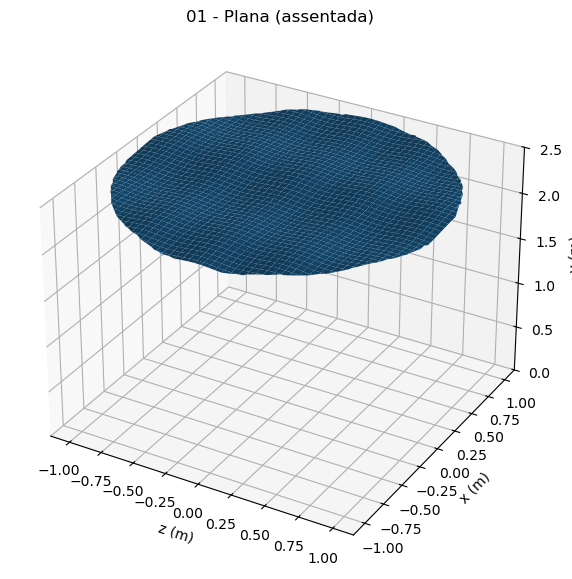

In [10]:
SUPERFICIE_ID = 1

item = next(
    superficie
    for superficie in catalogo
    if superficie["id"] == SUPERFICIE_ID
)

Y = gerar_superficie(item)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Z, X, Y, linewidth=0, antialiased=True)

ax.set_title(f'{item["id"]:02d} - {item["tipo"]}')
ax.set_xlabel("z (m)")
ax.set_ylabel("x (m)")
ax.set_zlabel("y (m)")
ax.set_xlim(-R, R)
ax.set_ylim(-R, R)
ax.set_zlim(0, H)

plt.show()


## 7. Gerar as 45 superfícies

Para cada configuração, esta célula salva:

- um `.png` para inspeção visual;
- um `.npz` contendo `X`, `Z` e `Y`, que pode ser reutilizado depois na etapa de posicionamento do sensor;
- um `manifesto.csv` com o índice dos arquivos.

Cada figura é gerada separadamente.


In [8]:
def salvar_superficie(item):
    Y = gerar_superficie(item)

    nome_base = f'superficie_{item["id"]:03d}'

    np.savez_compressed(
        OUTPUT_DIR / f"{nome_base}.npz",
        X=X,
        Z=Z,
        Y=Y,
    )

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(Z, X, Y, linewidth=0, antialiased=True)

    ax.set_title(f'{item["id"]:02d} - {item["tipo"]}')
    ax.set_xlabel("z (m)")
    ax.set_ylabel("x (m)")
    ax.set_zlabel("y (m)")
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.set_zlim(0, H)

    fig.savefig(
        OUTPUT_DIR / f"{nome_base}.png",
        dpi=140,
        bbox_inches="tight",
    )

    plt.close(fig)

    return nome_base


manifesto = []

for item in catalogo:
    nome_base = salvar_superficie(item)

    manifesto.append(
        [
            item["id"],
            item["tipo"],
            f"{nome_base}.png",
            f"{nome_base}.npz",
        ]
    )

print(f"{len(manifesto)} superfícies geradas em: {OUTPUT_DIR.resolve()}")


45 superfícies geradas em: /mnt/data/notebook_atualizado/superficies_geradas


## 8. Conferência rápida

Esta célula verifica se todas as superfícies foram produzidas e mostra os intervalos de altura resultantes.


In [8]:
for item in catalogo:
    Y = gerar_superficie(item)

    print(
        f'{item["id"]:02d}',
        item["tipo"],
        f'min={np.nanmin(Y):.3f} m',
        f'max={np.nanmax(Y):.3f} m',
    )


01 Plana (assentada) min=2.345 m max=2.405 m
02 Plana (assentada) min=1.595 m max=1.655 m
03 Plana (assentada) min=1.970 m max=2.030 m
04 Plana (assentada) min=2.345 m max=2.405 m
05 Plana (assentada) min=1.970 m max=2.030 m
06 Monte lateral com cratera central min=0.932 m max=1.579 m
07 Monte lateral com cratera central min=0.989 m max=1.532 m
08 Monte lateral com cratera central min=0.932 m max=1.597 m
09 Monte lateral com cratera central min=0.950 m max=1.559 m
10 Monte lateral com cratera central min=1.041 m max=1.478 m
11 Cratera de descarga min=1.141 m max=1.360 m
12 Cratera de descarga min=1.039 m max=1.464 m
13 Cratera de descarga min=0.990 m max=1.510 m
14 Cratera de descarga min=0.944 m max=1.555 m
15 Cratera de descarga min=1.139 m max=1.361 m
16 Monte deslocado (boca lateral) min=0.895 m max=1.591 m
17 Monte deslocado (boca lateral) min=0.820 m max=1.680 m
18 Monte deslocado (boca lateral) min=0.809 m max=1.636 m
19 Monte deslocado (boca lateral) min=0.816 m max=1.669 m
20 